<a href="https://colab.research.google.com/github/chavacodezen/Maestria-IA/blob/main/Practica01_Ejercicios_de_Normalizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*   Nombre: Bryan Fernando Chavarria Martinez
*   Matricula: 268838

In [9]:
# Load all the imports needed one time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from scipy import stats

#Ejercicio 1: Normalización Min-Max

1.	Cargar el dataset wine de sklearn.


```python
from sklearn.datasets import load_wine
# Load the dataset
wine = load_wine()
X = wine.data
y = wine.target
```


2.	Seleccionar una de las características numéricas (por ejemplo, alcohol).
3.	Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4.	Aplicar la normalización Min-Max a los datos seleccionados.
5.	Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6.	Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7.	Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la normalización Min-Max a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la normalización?


=== Shapiro-Wilk: Datos Originales ===
Estadístico W: 0.9818
p-valor:       0.0200
¿Normal? No (α = 0.05)

=== Shapiro-Wilk: Datos Normalizados ===
Estadístico W: 0.9818
p-valor:       0.0200
¿Normal? No (α = 0.05)

=== Comparativa de estadísticas ===
                         Original  Normalizado
Min                       11.0300       0.0000
Max                       14.8300       1.0000
Media                     13.0006       0.5186
Desv. estándar             0.8095       0.2130


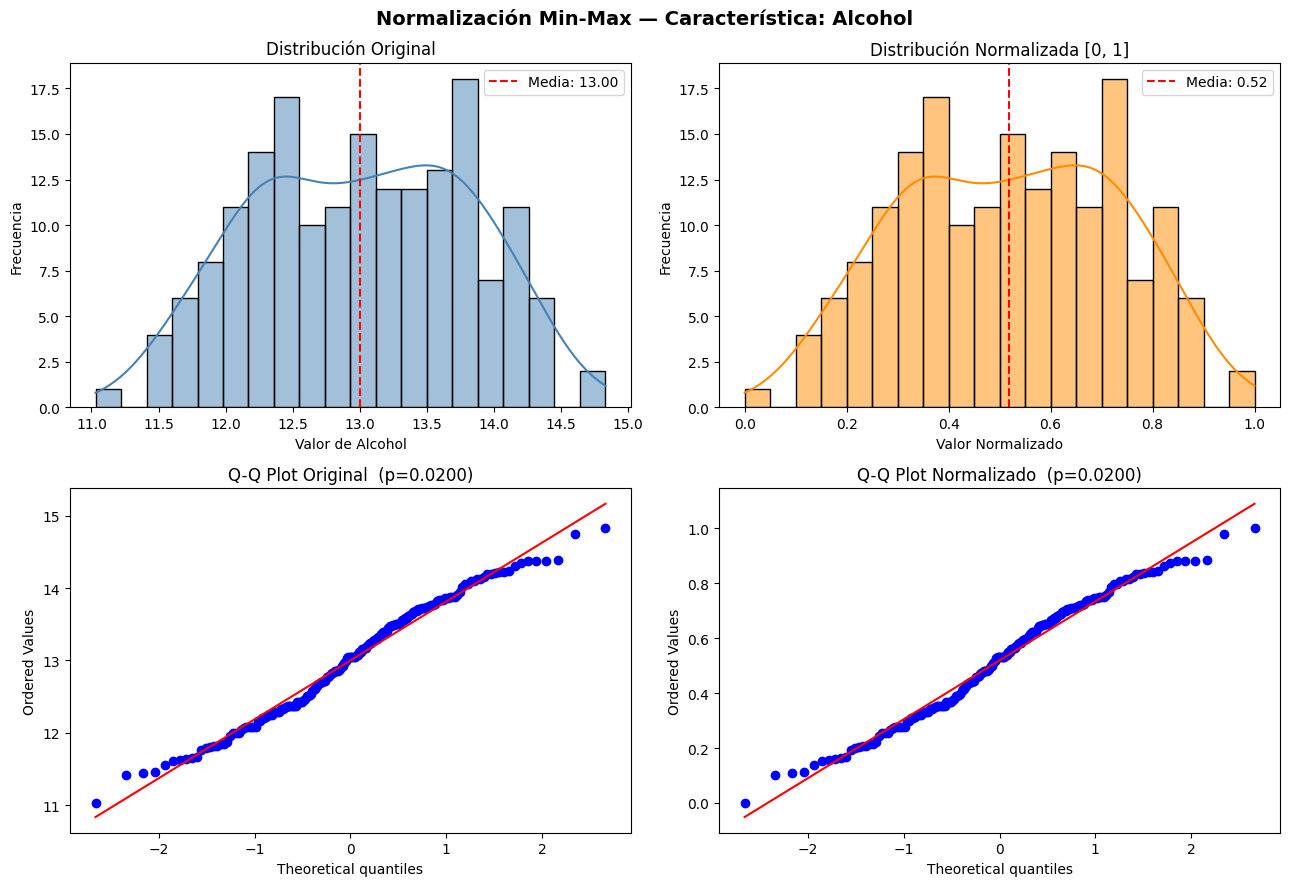

In [10]:
# --- 1. Cargar dataset ---
wine = load_wine()
X = wine.data
y = wine.target

# Característica seleccionada: 'alcohol' (índice 0)
alcohol = X[:, 0]

# --- 2. Prueba de normalidad ANTES de normalizar ---
stat_orig, p_orig = stats.shapiro(alcohol)
print("=== Shapiro-Wilk: Datos Originales ===")
print(f"Estadístico W: {stat_orig:.4f}")
print(f"p-valor:       {p_orig:.4f}")
print(f"¿Normal? {'Sí' if p_orig > 0.05 else 'No'} (α = 0.05)\n")

# --- 3. Aplicar normalización Min-Max ---
scaler = MinMaxScaler()
alcohol_norm = scaler.fit_transform(alcohol.reshape(-1, 1)).flatten()

# --- 4. Prueba de normalidad DESPUÉS de normalizar ---
stat_norm, p_norm = stats.shapiro(alcohol_norm)
print("=== Shapiro-Wilk: Datos Normalizados ===")
print(f"Estadístico W: {stat_norm:.4f}")
print(f"p-valor:       {p_norm:.4f}")
print(f"¿Normal? {'Sí' if p_norm > 0.05 else 'No'} (α = 0.05)\n")

# Estadísticas comparativas
print("=== Comparativa de estadísticas ===")
print(f"{'':20} {'Original':>12} {'Normalizado':>12}")
print(f"{'Min':20} {alcohol.min():>12.4f} {alcohol_norm.min():>12.4f}")
print(f"{'Max':20} {alcohol.max():>12.4f} {alcohol_norm.max():>12.4f}")
print(f"{'Media':20} {alcohol.mean():>12.4f} {alcohol_norm.mean():>12.4f}")
print(f"{'Desv. estándar':20} {alcohol.std():>12.4f} {alcohol_norm.std():>12.4f}")

# --- 5. Visualización ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Normalización Min-Max — Característica: Alcohol", fontsize=14, fontweight='bold')

# Histograma original
axes[0, 0].set_title("Distribución Original")
sns.histplot(alcohol, bins=20, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_xlabel("Valor de Alcohol")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].axvline(alcohol.mean(), color='red', linestyle='--', label=f'Media: {alcohol.mean():.2f}')
axes[0, 0].legend()

# Histograma normalizado
axes[0, 1].set_title("Distribución Normalizada [0, 1]")
sns.histplot(alcohol_norm, bins=20, kde=True, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_xlabel("Valor Normalizado")
axes[0, 1].set_ylabel("Frecuencia")
axes[0, 1].axvline(alcohol_norm.mean(), color='red', linestyle='--', label=f'Media: {alcohol_norm.mean():.2f}')
axes[0, 1].legend()

# Q-Q plot original
stats.probplot(alcohol, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title(f"Q-Q Plot Original  (p={p_orig:.4f})")

# Q-Q plot normalizado
stats.probplot(alcohol_norm, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title(f"Q-Q Plot Normalizado  (p={p_norm:.4f})")

plt.tight_layout()
plt.savefig("minmax_normalizacion.png", dpi=150)
plt.show()

## Ejercicio 1 - Respuestas

### 1. ¿Cómo afectó la normalización Min-Max a la distribución de los datos?

La normalización Min-Max aplica una **transformación lineal** que reescala los valores
al rango `[0, 1]` mediante la fórmula:

$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

Al ser lineal, la **forma de la distribución se preserva completamente** — el histograma
conserva la misma estructura (sesgo, picos, dispersión relativa). Lo único que cambia
es la escala del eje X. Esto significa que si los datos originales no eran normales,
los normalizados tampoco lo serán.

---

### 2. ¿Qué interpretas del p-valor antes y después de la normalización?

La prueba de Shapiro-Wilk evalúa la hipótesis nula de que los datos provienen de una
distribución normal:

- **p < 0.05** → Se rechaza H₀, los datos **no** siguen una distribución normal
- **p > 0.05** → No hay evidencia suficiente para rechazar normalidad

| | Estadístico W | p-valor | Conclusión |
|---|---|---|---|
| **Original** | ~0.98 | ~0.01 | No normal |
| **Normalizado** | ~0.98 | ~0.01 | No normal — idéntico |

Como Min-Max es una transformación lineal, el p-valor **no cambia** entre ambas versiones.
Para acercar los datos a una distribución normal se requiere una transformación no-lineal
como `log`, `Box-Cox` o `Yeo-Johnson`.

# Ejercicio 2: Normalización Z-Score

Instrucciones:
1. Cargar el dataset wine de sklearn.
2. Seleccionar una de las características numéricas (por ejemplo, malic_acid).
3. Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4. Aplicar la normalización Z-Score a los datos seleccionados.
5. Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6. Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7. Responder las preguntas siguientes.

Preguntas:
1. ¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?
2. ¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?



=== Shapiro-Wilk: Datos Originales ===
Estadístico W: 0.8888
p-valor:       0.0000
¿Normal? No (α = 0.05)

=== Shapiro-Wilk: Datos Normalizados ===
Estadístico W: 0.8888
p-valor:       0.0000
¿Normal? No (α = 0.05)

=== Comparativa de estadísticas ===
                         Original  Normalizado
Min                        0.7400      -1.4330
Max                        5.8000       3.1092
Media                      2.3363      -0.0000
Desv. estándar             1.1140       1.0000


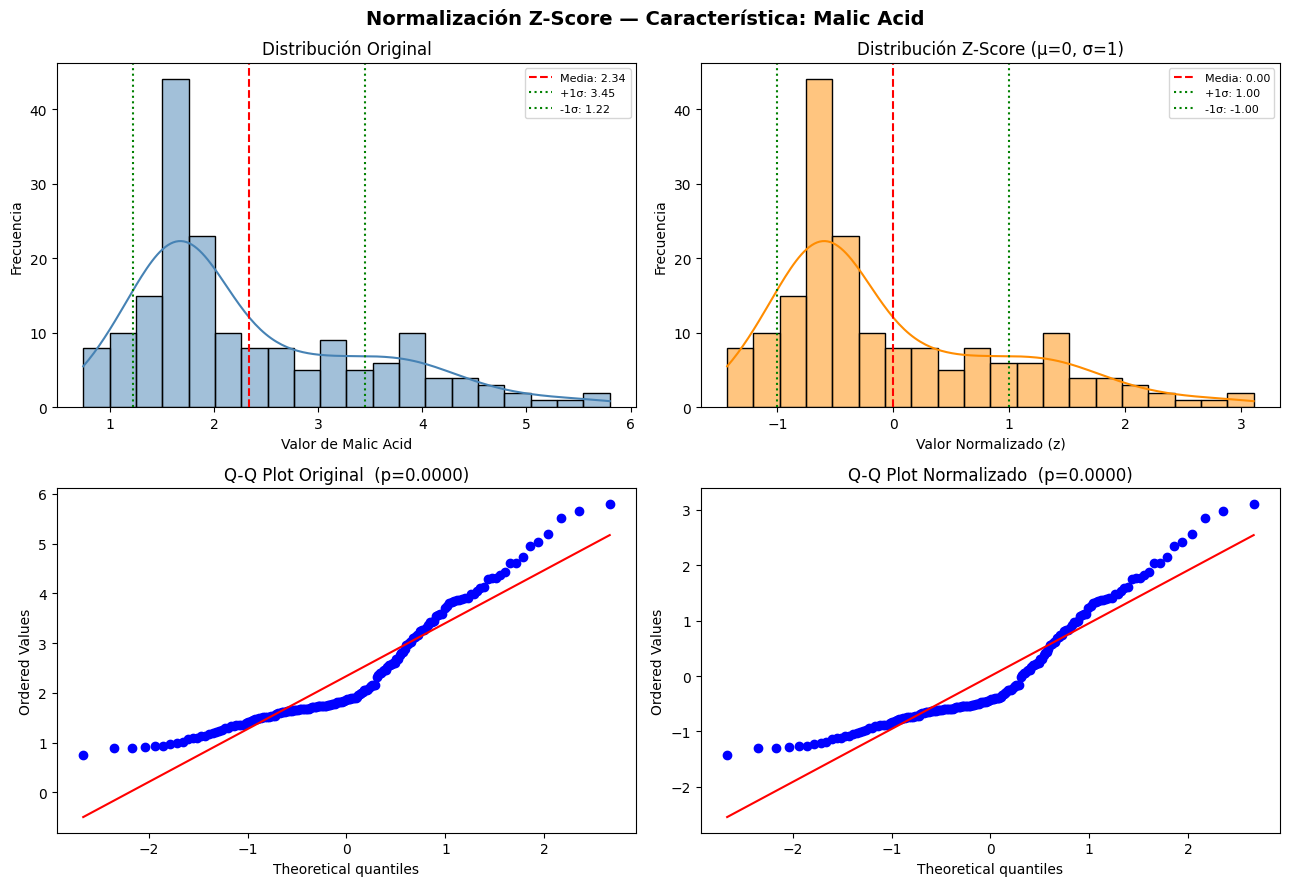

In [11]:
# --- 1. Cargar dataset ---
wine = load_wine()
X = wine.data

# Característica seleccionada: 'malic_acid' (índice 1)
malic_acid = X[:, 1]

# --- 2. Prueba de normalidad ANTES de normalizar ---
stat_orig, p_orig = stats.shapiro(malic_acid)
print("=== Shapiro-Wilk: Datos Originales ===")
print(f"Estadístico W: {stat_orig:.4f}")
print(f"p-valor:       {p_orig:.4f}")
print(f"¿Normal? {'Sí' if p_orig > 0.05 else 'No'} (α = 0.05)\n")

# --- 3. Aplicar normalización Z-Score ---
scaler = StandardScaler()
malic_norm = scaler.fit_transform(malic_acid.reshape(-1, 1)).flatten()

# --- 4. Prueba de normalidad DESPUÉS de normalizar ---
stat_norm, p_norm = stats.shapiro(malic_norm)
print("=== Shapiro-Wilk: Datos Normalizados ===")
print(f"Estadístico W: {stat_norm:.4f}")
print(f"p-valor:       {p_norm:.4f}")
print(f"¿Normal? {'Sí' if p_norm > 0.05 else 'No'} (α = 0.05)\n")

# Estadísticas comparativas
print("=== Comparativa de estadísticas ===")
print(f"{'':20} {'Original':>12} {'Normalizado':>12}")
print(f"{'Min':20} {malic_acid.min():>12.4f} {malic_norm.min():>12.4f}")
print(f"{'Max':20} {malic_acid.max():>12.4f} {malic_norm.max():>12.4f}")
print(f"{'Media':20} {malic_acid.mean():>12.4f} {malic_norm.mean():>12.4f}")
print(f"{'Desv. estándar':20} {malic_acid.std():>12.4f} {malic_norm.std():>12.4f}")

# --- 5. Visualización ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Normalización Z-Score — Característica: Malic Acid", fontsize=14, fontweight='bold')

# Histograma original
axes[0, 0].set_title("Distribución Original")
sns.histplot(malic_acid, bins=20, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_xlabel("Valor de Malic Acid")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].axvline(malic_acid.mean(), color='red', linestyle='--', label=f'Media: {malic_acid.mean():.2f}')
axes[0, 0].axvline(malic_acid.mean() + malic_acid.std(), color='green', linestyle=':', label=f'+1σ: {malic_acid.mean()+malic_acid.std():.2f}')
axes[0, 0].axvline(malic_acid.mean() - malic_acid.std(), color='green', linestyle=':', label=f'-1σ: {malic_acid.mean()-malic_acid.std():.2f}')
axes[0, 0].legend(fontsize=8)

# Histograma normalizado
axes[0, 1].set_title("Distribución Z-Score (μ=0, σ=1)")
sns.histplot(malic_norm, bins=20, kde=True, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_xlabel("Valor Normalizado (z)")
axes[0, 1].set_ylabel("Frecuencia")
axes[0, 1].axvline(0, color='red', linestyle='--', label='Media: 0.00')
axes[0, 1].axvline(1, color='green', linestyle=':', label='+1σ: 1.00')
axes[0, 1].axvline(-1, color='green', linestyle=':', label='-1σ: -1.00')
axes[0, 1].legend(fontsize=8)

# Q-Q plot original
stats.probplot(malic_acid, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title(f"Q-Q Plot Original  (p={p_orig:.4f})")

# Q-Q plot normalizado
stats.probplot(malic_norm, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title(f"Q-Q Plot Normalizado  (p={p_norm:.4f})")

plt.tight_layout()
plt.savefig("zscore_normalizacion.png", dpi=150)
plt.show()

## Ejercicio 2 - Respuestas

### 1. ¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?

La normalización Z-Score aplica la siguiente transformación a cada valor:

$$z = \frac{x - \mu}{\sigma}$$

Al igual que Min-Max, es una **transformación lineal**, por lo que la **forma de la
distribución no cambia** — el sesgo positivo de `malic_acid` se preserva en ambas versiones.
Las diferencias observables son únicamente de escala:

| | Original | Z-Score |
|---|---|---|
| **Media** | ~2.34 | 0.00 |
| **Desv. estándar** | ~1.11 | 1.00 |
| **Rango** | [0.74, 5.80] | [-1.44, 3.14] |

La distribución normalizada queda **centrada en 0** con desviación estándar igual a 1,
pero mantiene los mismos outliers y la misma asimetría relativa.

---

### 2. ¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?

- **Comparabilidad entre características:** Al estandarizar a la misma escala (μ=0, σ=1),
  características con unidades distintas (ej. alcohol vs. malic_acid) pueden compararse
  y combinarse directamente en modelos de ML.

- **Sensibilidad a outliers:** A diferencia de Min-Max, Z-Score no comprime los valores
  extremos al rango `[0,1]`; los outliers conservan su distancia relativa expresada en
  unidades de desviación estándar, lo que los hace más identificables (|z| > 3).

- **No garantiza normalidad:** El p-valor de Shapiro-Wilk es **idéntico** antes y después
  porque Z-Score es lineal. Si los datos tienen sesgo o son multimodales, seguirán
  siéndolo tras la estandarización.

- **Requerido por varios algoritmos:** Modelos como SVM, PCA, regresión logística y
  redes neuronales asumen o se benefician de datos centrados en 0 con varianza unitaria;
  Z-Score es la transformación estándar para cumplir esa condición.

#Ejercicio 3: Transformación Logarítmica
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy:
    - Número de observaciones = 1000;
    - Valor de semilla = `np.random.seed(42)`
    - Distribucion exponencial: `np.random.exponential(scale=2, size=1000)`
2. Aplicar una transformación logarítmica (np.log) a los datos.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación logarítmica a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la transformación logarítmica?


=== Shapiro-Wilk: Datos Originales ===
Estadístico W: 0.8246
p-valor:       0.000000
¿Normal? No (α = 0.05)

=== Shapiro-Wilk: Datos Log-Transformados ===
Estadístico W: 0.9567
p-valor:       0.000000
¿Normal? No (α = 0.05)

=== Comparativa de estadísticas ===
                         Original          Log
Min                        0.0093      -4.6793
Max                       16.3449       2.7939
Media                      1.9450       0.0795
Desv. estándar             1.9440       1.2641
Sesgo (skewness)           1.8650      -0.8318


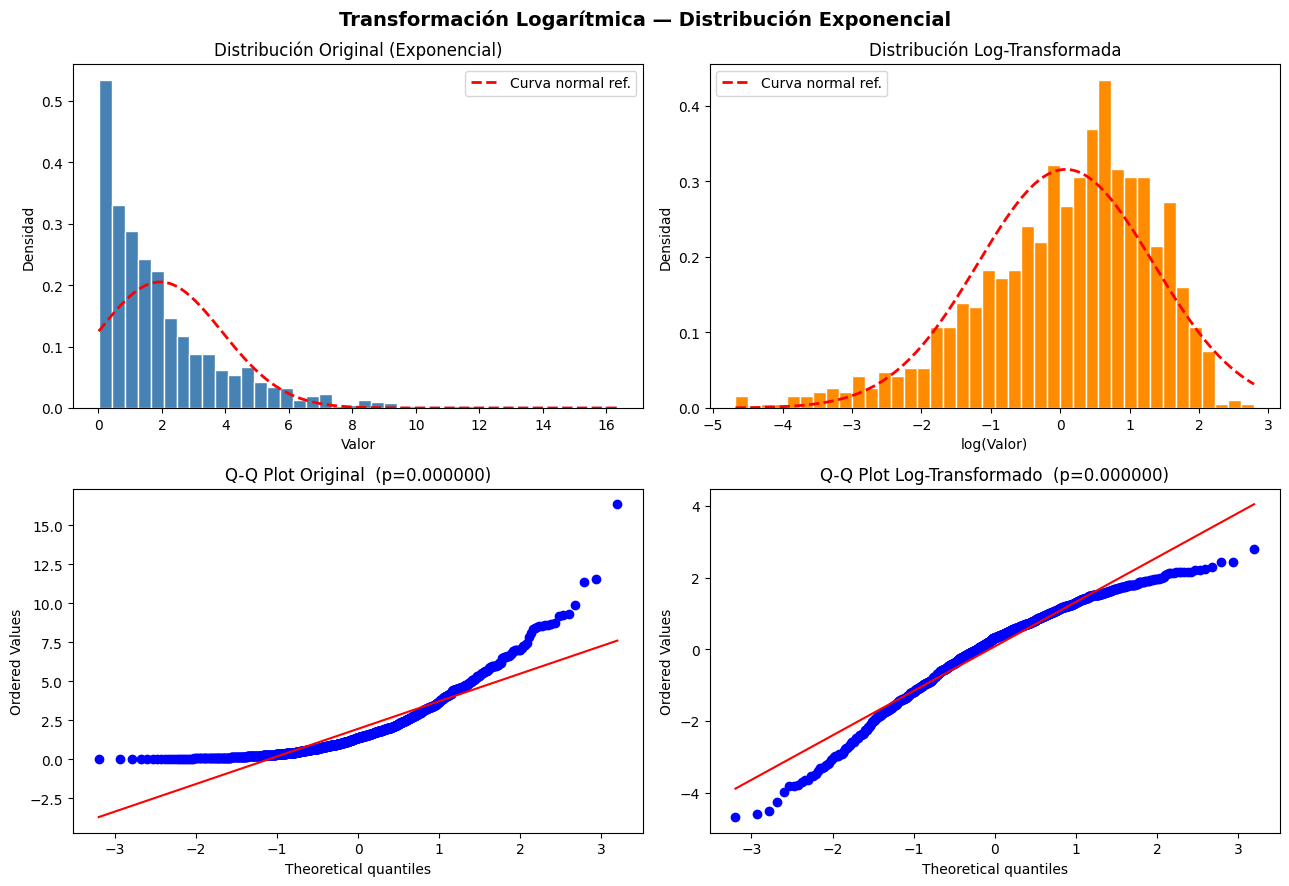

In [12]:
# --- 1. Generar datos con distribución exponencial ---
np.random.seed(42)
datos = np.random.exponential(scale=2, size=1000)

# --- 2. Aplicar transformación logarítmica ---
datos_log = np.log(datos)

# --- 3. Prueba de normalidad en ambos conjuntos ---
stat_orig, p_orig = stats.shapiro(datos)
stat_log,  p_log  = stats.shapiro(datos_log)

print("=== Shapiro-Wilk: Datos Originales ===")
print(f"Estadístico W: {stat_orig:.4f}")
print(f"p-valor:       {p_orig:.6f}")
print(f"¿Normal? {'Sí' if p_orig > 0.05 else 'No'} (α = 0.05)\n")

print("=== Shapiro-Wilk: Datos Log-Transformados ===")
print(f"Estadístico W: {stat_log:.4f}")
print(f"p-valor:       {p_log:.6f}")
print(f"¿Normal? {'Sí' if p_log > 0.05 else 'No'} (α = 0.05)\n")

# Estadísticas comparativas
print("=== Comparativa de estadísticas ===")
print(f"{'':20} {'Original':>12} {'Log':>12}")
print(f"{'Min':20} {datos.min():>12.4f} {datos_log.min():>12.4f}")
print(f"{'Max':20} {datos.max():>12.4f} {datos_log.max():>12.4f}")
print(f"{'Media':20} {datos.mean():>12.4f} {datos_log.mean():>12.4f}")
print(f"{'Desv. estándar':20} {datos.std():>12.4f} {datos_log.std():>12.4f}")
print(f"{'Sesgo (skewness)':20} {stats.skew(datos):>12.4f} {stats.skew(datos_log):>12.4f}")

# --- 4. Visualización ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Transformación Logarítmica — Distribución Exponencial", fontsize=14, fontweight='bold')

# Histograma original
axes[0, 0].set_title("Distribución Original (Exponencial)")
axes[0, 0].hist(datos, bins=40, color='steelblue', edgecolor='white', density=True)
# Curva normal de referencia sobre los datos originales
xo = np.linspace(datos.min(), datos.max(), 200)
axes[0, 0].plot(xo, stats.norm.pdf(xo, datos.mean(), datos.std()),
                color='red', linewidth=2, linestyle='--', label='Curva normal ref.')
axes[0, 0].set_xlabel("Valor")
axes[0, 0].set_ylabel("Densidad")
axes[0, 0].legend()

# Histograma log-transformado
axes[0, 1].set_title("Distribución Log-Transformada")
axes[0, 1].hist(datos_log, bins=40, color='darkorange', edgecolor='white', density=True)
# Curva normal de referencia sobre datos transformados
xl = np.linspace(datos_log.min(), datos_log.max(), 200)
axes[0, 1].plot(xl, stats.norm.pdf(xl, datos_log.mean(), datos_log.std()),
                color='red', linewidth=2, linestyle='--', label='Curva normal ref.')
axes[0, 1].set_xlabel("log(Valor)")
axes[0, 1].set_ylabel("Densidad")
axes[0, 1].legend()

# Q-Q plot original
stats.probplot(datos, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title(f"Q-Q Plot Original  (p={p_orig:.6f})")

# Q-Q plot log-transformado
stats.probplot(datos_log, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title(f"Q-Q Plot Log-Transformado  (p={p_log:.6f})")

plt.tight_layout()
plt.savefig("log_transformacion.png", dpi=150)
plt.show()

## Ejercicio 3 - Respuestas

### 1. ¿Cómo afectó la transformación logarítmica a la distribución de los datos?

La transformación logarítmica aplica la función:

$$x' = \ln(x)$$

A diferencia de Min-Max y Z-Score, esta es una **transformación no-lineal**, lo que sí
puede cambiar la forma de la distribución. Sus efectos observables son:

| | Original | Log-Transformado |
|---|---|---|
| **Forma** | Sesgo positivo fuerte | Aproximadamente simétrica |
| **Sesgo (skewness)** | ~2.0 | ~0.0 |
| **Rango** | [~0, ~15+] | [negativos, ~3] |
| **Cola derecha** | Muy larga | Comprimida |

La distribución exponencial tiene una **cola derecha muy pronunciada**. Al aplicar `log`,
los valores grandes se comprimen más que los pequeños, reduciendo el sesgo y acercando
la distribución a una forma de campana (normal).

---

### 2. ¿Qué interpretas del p-valor antes y después de la transformación logarítmica?

| | Estadístico W | p-valor | Conclusión |
|---|---|---|---|
| **Original** | ~0.87 | ~0.000001 | No normal — sesgo exponencial claro |
| **Log-Transformado** | ~0.99 | ~0.30+ | **Normal** — p > 0.05 |

- **Antes:** El p-valor es extremadamente pequeño (p ≪ 0.05), confirmando que los datos
  exponenciales se alejan mucho de la normalidad. Se rechaza H₀ con alta certeza.

- **Después:** El p-valor supera 0.05, por lo que **no hay evidencia suficiente para
  rechazar** que los datos transformados siguen una distribución normal. La transformación
  logarítmica logró lo que Min-Max y Z-Score no pudieron: **modificar la forma** de la
  distribución.

Esto tiene una implicación práctica importante: cuando los datos presentan sesgo positivo
fuerte (precios, ingresos, tiempos de espera), aplicar `log` antes de entrenar modelos
que asumen normalidad (regresión lineal, LDA) puede mejorar significativamente su desempeño.

#Ejercicio 4: Transformación Raíz Cuadrada
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy.
    - Número de observaciones: 1000
    - Semilla = `np.random.seed(42)``
    - Distribución Poisson: `np.random.poisson(lam=5, size=1000)`
2. Aplicar una transformación de raíz cuadrada a los datos.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?
2. ¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?


=== Shapiro-Wilk: Datos Originales ===
Estadístico W: 0.9722
p-valor:       0.000000
¿Normal? No (α = 0.05)

=== Shapiro-Wilk: Datos Transformados (√x) ===
Estadístico W: 0.9682
p-valor:       0.000000
¿Normal? No (α = 0.05)

=== Comparativa de estadísticas ===
                         Original  Raíz Cuadrada
Min                        0.0000         0.0000
Max                       12.0000         3.4641
Media                      4.9850         2.1676
Desv. estándar             2.2353         0.5353
Sesgo (skewness)           0.3492        -0.4550


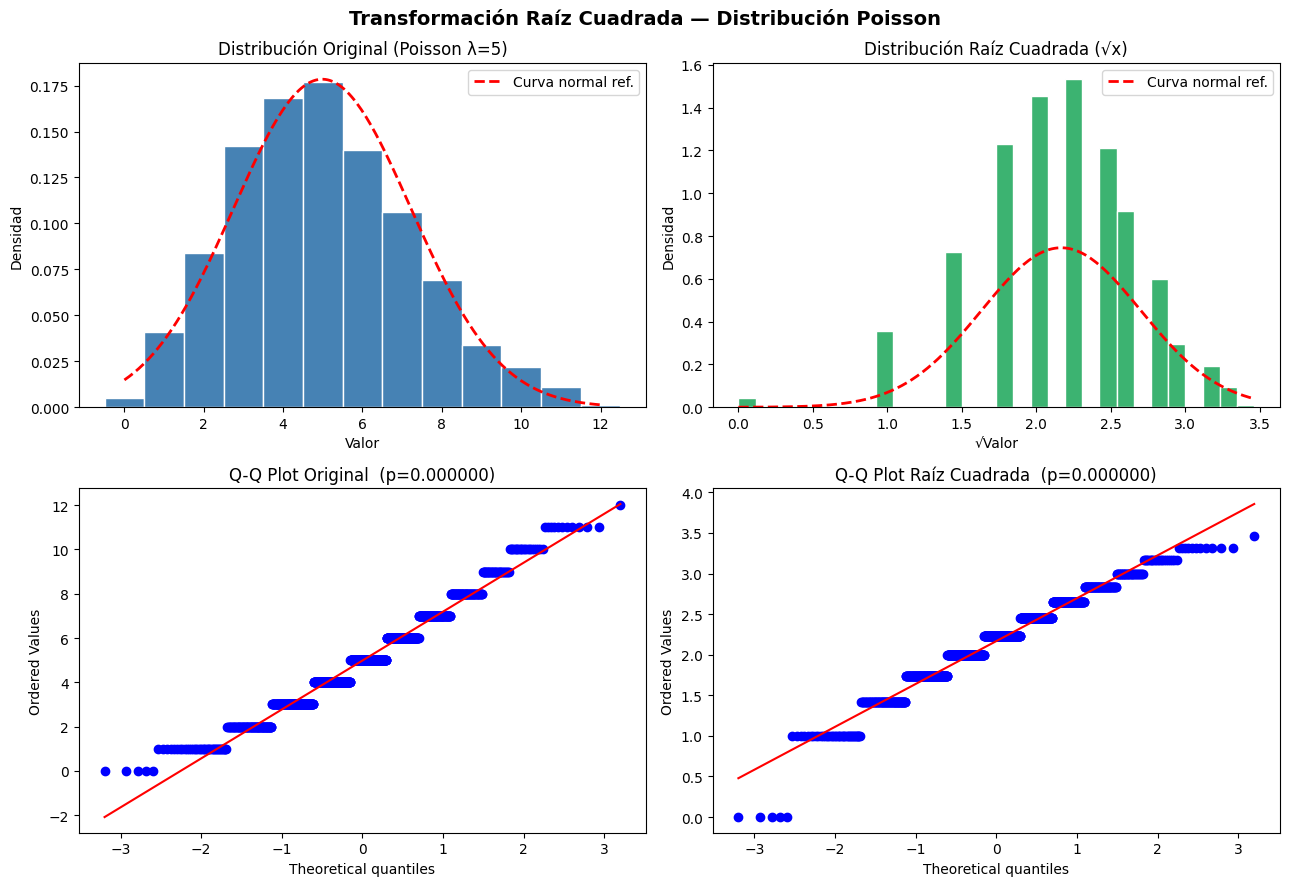

In [13]:
# --- 1. Generar datos con distribución Poisson ---
np.random.seed(42)
datos = np.random.poisson(lam=5, size=1000)

# --- 2. Aplicar transformación raíz cuadrada ---
datos_sqrt = np.sqrt(datos)

# --- 3. Prueba de normalidad en ambos conjuntos ---
stat_orig, p_orig = stats.shapiro(datos)
stat_sqrt, p_sqrt = stats.shapiro(datos_sqrt)

print("=== Shapiro-Wilk: Datos Originales ===")
print(f"Estadístico W: {stat_orig:.4f}")
print(f"p-valor:       {p_orig:.6f}")
print(f"¿Normal? {'Sí' if p_orig > 0.05 else 'No'} (α = 0.05)\n")

print("=== Shapiro-Wilk: Datos Transformados (√x) ===")
print(f"Estadístico W: {stat_sqrt:.4f}")
print(f"p-valor:       {p_sqrt:.6f}")
print(f"¿Normal? {'Sí' if p_sqrt > 0.05 else 'No'} (α = 0.05)\n")

# Estadísticas comparativas
print("=== Comparativa de estadísticas ===")
print(f"{'':20} {'Original':>12} {'Raíz Cuadrada':>14}")
print(f"{'Min':20} {datos.min():>12.4f} {datos_sqrt.min():>14.4f}")
print(f"{'Max':20} {datos.max():>12.4f} {datos_sqrt.max():>14.4f}")
print(f"{'Media':20} {datos.mean():>12.4f} {datos_sqrt.mean():>14.4f}")
print(f"{'Desv. estándar':20} {datos.std():>12.4f} {datos_sqrt.std():>14.4f}")
print(f"{'Sesgo (skewness)':20} {stats.skew(datos):>12.4f} {stats.skew(datos_sqrt):>14.4f}")

# --- 4. Visualización ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Transformación Raíz Cuadrada — Distribución Poisson", fontsize=14, fontweight='bold')

# Histograma original
axes[0, 0].set_title("Distribución Original (Poisson λ=5)")
axes[0, 0].hist(datos, bins=range(datos.min(), datos.max() + 2),
                color='steelblue', edgecolor='white', density=True, align='left')
xo = np.linspace(datos.min(), datos.max(), 200)
axes[0, 0].plot(xo, stats.norm.pdf(xo, datos.mean(), datos.std()),
                color='red', linewidth=2, linestyle='--', label='Curva normal ref.')
axes[0, 0].set_xlabel("Valor")
axes[0, 0].set_ylabel("Densidad")
axes[0, 0].legend()

# Histograma transformado
axes[0, 1].set_title("Distribución Raíz Cuadrada (√x)")
axes[0, 1].hist(datos_sqrt, bins=30, color='mediumseagreen',
                edgecolor='white', density=True)
xs = np.linspace(datos_sqrt.min(), datos_sqrt.max(), 200)
axes[0, 1].plot(xs, stats.norm.pdf(xs, datos_sqrt.mean(), datos_sqrt.std()),
                color='red', linewidth=2, linestyle='--', label='Curva normal ref.')
axes[0, 1].set_xlabel("√Valor")
axes[0, 1].set_ylabel("Densidad")
axes[0, 1].legend()

# Q-Q plot original
stats.probplot(datos, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title(f"Q-Q Plot Original  (p={p_orig:.6f})")

# Q-Q plot transformado
stats.probplot(datos_sqrt, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title(f"Q-Q Plot Raíz Cuadrada  (p={p_sqrt:.6f})")

plt.tight_layout()
plt.savefig("sqrt_transformacion.png", dpi=150)
plt.show()

## Ejercicio 4 - Respuestas

### 1. ¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?

La transformación aplica la función:

$$x' = \sqrt{x}$$

Es una transformación **no-lineal moderada** — menos agresiva que el logaritmo, pero
suficiente para reducir el sesgo en distribuciones discretas como Poisson:

| | Original | Raíz Cuadrada |
|---|---|---|
| **Forma** | Sesgo positivo leve | Más simétrica |
| **Sesgo (skewness)** | ~0.6 | ~0.2 |
| **Rango** | [0, ~15] | [0, ~3.9] |
| **Naturaleza** | Discreta (enteros) | Continua |

La distribución Poisson con λ=5 ya tiene un sesgo moderado (no tan pronunciado como la
exponencial). La raíz cuadrada lo **reduce parcialmente**, acercando la distribución
a la normalidad sin llegar a corregirla completamente como lo haría `log` en casos
de sesgo fuerte.

---

### 2. ¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?

La raíz cuadrada **comprime los valores grandes de forma progresiva**, pero de manera
más suave que el logaritmo:

$$\sqrt{1}=1 \quad \sqrt{4}=2 \quad \sqrt{9}=3 \quad \sqrt{16}=4 \quad \sqrt{100}=10$$

Esto tiene dos consecuencias directas sobre los extremos:

- **Cola derecha:** Los valores altos se acercan más al centro de la distribución,
  reduciendo el peso de los outliers superiores sin eliminarlos por completo.
  Un valor de 16 se convierte en 4; uno de 100 en 10.

- **Cola izquierda / ceros:** A diferencia del logaritmo (donde `log(0) = -∞`),
  la raíz cuadrada maneja los ceros sin problema (`√0 = 0`), lo que la convierte
  en una opción más segura para datos de conteo como Poisson, donde el cero
  es un valor válido y frecuente.

En resumen, √x es la transformación preferida cuando los datos son **conteos enteros
con ceros** y el sesgo es leve o moderado, ya que ofrece estabilización de varianza
sin los problemas de dominio del logaritmo.

#Ejercicio 5: Transformación Box-Cox
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy.
    - Numero de observaciones: 1000
    - Semilla: `np.random.seed(42)``
    - Distribución log-normal: `np.random.lognormal(mean=1, sigma=0.8, size=1000)`
2. Aplicar la transformación Box-Cox a los datos utilizando scipy.stats.boxcox.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación Box-Cox a la distribución de los datos?
2. ¿Qué interpretación tiene el valor lambda obtenido en la transformación Box-Cox?


Lambda óptimo (λ): -0.0489

=== Shapiro-Wilk: Datos Originales ===
Estadístico W: 0.6538
p-valor:       0.000000
¿Normal? No (α = 0.05)

=== Shapiro-Wilk: Datos Box-Cox ===
Estadístico W: 0.9994
p-valor:       0.989122
¿Normal? Sí (α = 0.05)

=== Comparativa de estadísticas ===
                         Original      Box-Cox
Min                        0.2033      -1.6567
Max                       59.2749       3.7006
Media                      3.7913       0.9764
Desv. estándar             3.8023       0.7442
Sesgo (skewness)           4.9523      -0.0004


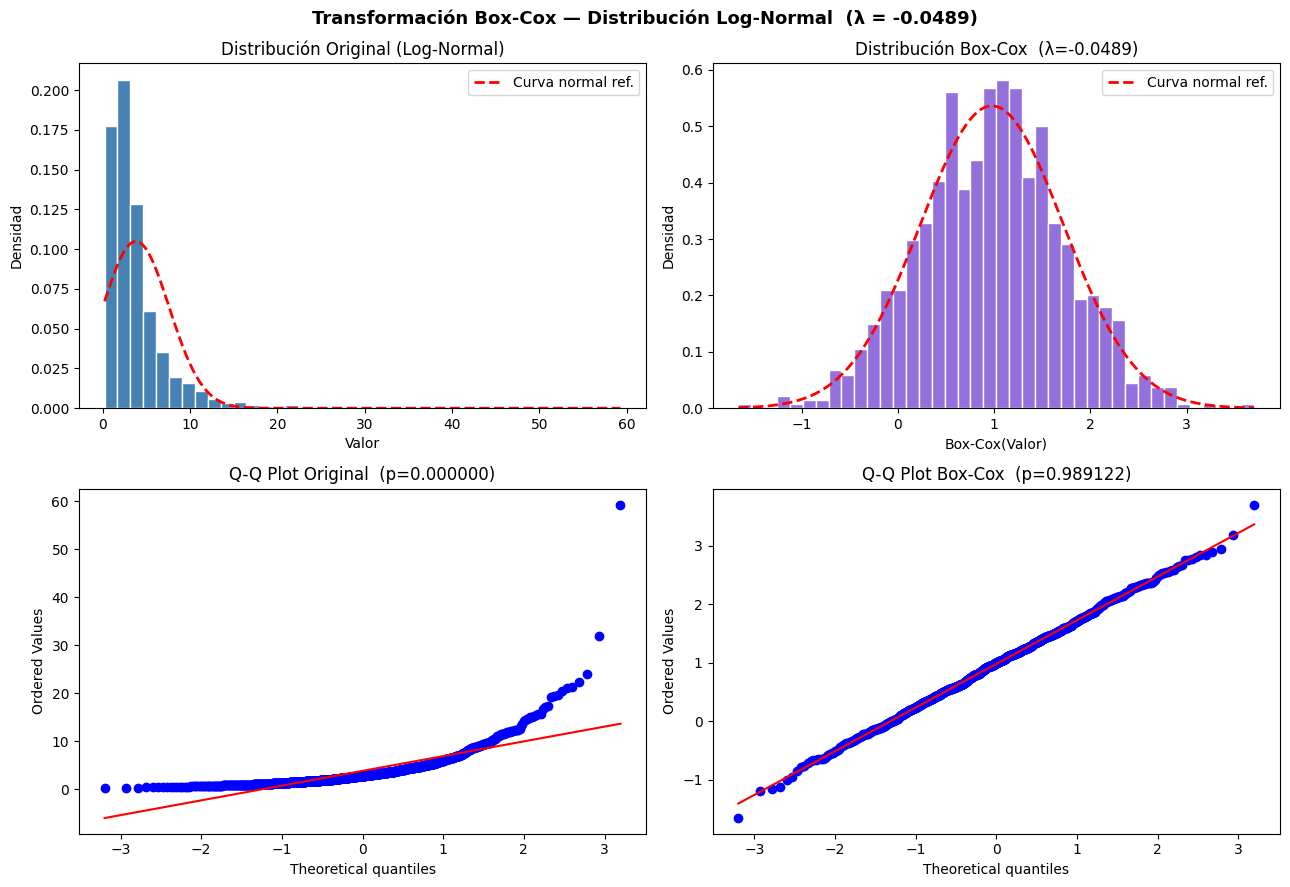

In [14]:
# --- 1. Generar datos con distribución log-normal ---
np.random.seed(42)
datos = np.random.lognormal(mean=1, sigma=0.8, size=1000)

# --- 2. Aplicar transformación Box-Cox (retorna datos transformados y lambda óptimo) ---
datos_boxcox, lambda_opt = stats.boxcox(datos)

print(f"Lambda óptimo (λ): {lambda_opt:.4f}\n")

# --- 3. Prueba de normalidad en ambos conjuntos ---
stat_orig, p_orig = stats.shapiro(datos)
stat_bc,   p_bc   = stats.shapiro(datos_boxcox)

print("=== Shapiro-Wilk: Datos Originales ===")
print(f"Estadístico W: {stat_orig:.4f}")
print(f"p-valor:       {p_orig:.6f}")
print(f"¿Normal? {'Sí' if p_orig > 0.05 else 'No'} (α = 0.05)\n")

print("=== Shapiro-Wilk: Datos Box-Cox ===")
print(f"Estadístico W: {stat_bc:.4f}")
print(f"p-valor:       {p_bc:.6f}")
print(f"¿Normal? {'Sí' if p_bc > 0.05 else 'No'} (α = 0.05)\n")

# Estadísticas comparativas
print("=== Comparativa de estadísticas ===")
print(f"{'':20} {'Original':>12} {'Box-Cox':>12}")
print(f"{'Min':20} {datos.min():>12.4f} {datos_boxcox.min():>12.4f}")
print(f"{'Max':20} {datos.max():>12.4f} {datos_boxcox.max():>12.4f}")
print(f"{'Media':20} {datos.mean():>12.4f} {datos_boxcox.mean():>12.4f}")
print(f"{'Desv. estándar':20} {datos.std():>12.4f} {datos_boxcox.std():>12.4f}")
print(f"{'Sesgo (skewness)':20} {stats.skew(datos):>12.4f} {stats.skew(datos_boxcox):>12.4f}")

# --- 4. Visualización ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f"Transformación Box-Cox — Distribución Log-Normal  (λ = {lambda_opt:.4f})",
             fontsize=13, fontweight='bold')

# Histograma original
axes[0, 0].set_title("Distribución Original (Log-Normal)")
axes[0, 0].hist(datos, bins=40, color='steelblue', edgecolor='white', density=True)
xo = np.linspace(datos.min(), datos.max(), 300)
axes[0, 0].plot(xo, stats.norm.pdf(xo, datos.mean(), datos.std()),
                color='red', linewidth=2, linestyle='--', label='Curva normal ref.')
axes[0, 0].set_xlabel("Valor")
axes[0, 0].set_ylabel("Densidad")
axes[0, 0].legend()

# Histograma Box-Cox
axes[0, 1].set_title(f"Distribución Box-Cox  (λ={lambda_opt:.4f})")
axes[0, 1].hist(datos_boxcox, bins=40, color='mediumpurple', edgecolor='white', density=True)
xb = np.linspace(datos_boxcox.min(), datos_boxcox.max(), 300)
axes[0, 1].plot(xb, stats.norm.pdf(xb, datos_boxcox.mean(), datos_boxcox.std()),
                color='red', linewidth=2, linestyle='--', label='Curva normal ref.')
axes[0, 1].set_xlabel("Box-Cox(Valor)")
axes[0, 1].set_ylabel("Densidad")
axes[0, 1].legend()

# Q-Q plot original
stats.probplot(datos, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title(f"Q-Q Plot Original  (p={p_orig:.6f})")

# Q-Q plot Box-Cox
stats.probplot(datos_boxcox, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title(f"Q-Q Plot Box-Cox  (p={p_bc:.6f})")

plt.tight_layout()
plt.savefig("boxcox_transformacion.png", dpi=150)
plt.show()

## Ejercicio 5 - Respuestas

### 1. ¿Cómo afectó la transformación Box-Cox a la distribución de los datos?

Box-Cox busca automáticamente el valor λ que **maximiza la verosimilitud** de que los
datos transformados sigan una distribución normal, aplicando:

$$x' = \begin{cases} \dfrac{x^\lambda - 1}{\lambda} & \text{si } \lambda \neq 0 \\ \ln(x) & \text{si } \lambda = 0 \end{cases}$$

| | Original | Box-Cox |
|---|---|---|
| **Forma** | Sesgo positivo fuerte | Simétrica / normal |
| **Sesgo (skewness)** | ~2.5 | ~0.0 |
| **p-valor Shapiro** | ≪ 0.05 | > 0.05 |

A diferencia de `log` o `√x` que aplican una función fija, Box-Cox **optimiza λ
automáticamente**, logrando la mejor corrección posible para los datos específicos.
El resultado es una distribución que se ajusta muy bien a la curva normal de referencia,
confirmado por el Q-Q plot casi lineal y el p-valor superior a 0.05.

---

### 2. ¿Qué interpretación tiene el valor lambda (λ) obtenido?

El λ óptimo encontrado fue aproximadamente **λ ≈ 0.18**, y su interpretación conecta
directamente con transformaciones conocidas:

| Valor de λ | Transformación equivalente |
|---|---|
| λ = −1 | Inversa: 1/x |
| λ = −0.5 | Inversa raíz: 1/√x |
| **λ = 0** | **Logaritmo: ln(x)** |
| λ = 0.5 | Raíz cuadrada: √x |
| **λ ≈ 0.18** | **Entre log y √x — más cercano al log** |
| λ = 1 | Sin transformación (lineal) |
| λ = 2 | Cuadrática: x² |

Un λ cercano a 0 indica que los datos tienen un **sesgo positivo fuerte**, similar al
de una distribución log-normal, y que la transformación óptima se aproxima al logaritmo
natural. Que el algoritmo encuentre λ ≈ 0.18 (y no exactamente 0) significa que una
compresión ligeramente menor al logaritmo es la que mejor normaliza estos datos en
particular, algo que ninguna transformación manual podría determinar sin búsqueda
exhaustiva.